# DGA Multi-class Classification — SVM (Linear)

## 1. Imports

In [2]:
pip install -q scikit-learn umap-learn pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings, math, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import cdist

from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
import umap

SEED = 42
np.random.seed(SEED)
print('All imports OK')

All imports OK


## 2. Load Data & Define Labels

In [ ]:
dga_dataset = pd.read_csv('C:/Users/Admin/OneDrive - National University of Singapore/Documents/NUS/DSA4266/dsa4266_group2/data/dga_data.csv')

# Benign rows get their own class label
dga_dataset = dga_dataset.dropna(subset=['domain']).copy()
dga_dataset['subclass'] = dga_dataset['subclass'].fillna('legit')
dga_dataset.loc[dga_dataset['isDGA'] != 'dga', 'subclass'] = 'legit'

CLASSES = sorted(dga_dataset['subclass'].unique().tolist())
N_CLASSES = len(CLASSES)

print(f'Classes ({N_CLASSES}): {CLASSES}')
print()
print('Class distribution:')
print(dga_dataset['subclass'].value_counts().to_string())

Classes (8): ['bamital', 'cryptolocker', 'gameoverdga', 'goz', 'legit', 'necurs', 'newgoz', 'nivdort']

Class distribution:
subclass
legit           79998
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086


## 3. Feature Extraction — Character N-gram TF-IDF

In [ ]:
domains = dga_dataset['domain'].tolist()
labels = dga_dataset['subclass'].tolist()

print('Fitting TF-IDF on character n-grams (2-4)...')
tfidf = TfidfVectorizer(
    analyzer = 'char_wb',
    ngram_range  = (2, 4),
    max_features = 5000,
    sublinear_tf = True,
)
X_sparse = tfidf.fit_transform(domains)
X_dense  = X_sparse.toarray().astype(np.float32)

le = LabelEncoder()
y  = le.fit_transform(labels)

PALETTE = plt.cm.get_cmap('tab10', N_CLASSES)
CLASS_COLORS = {i: PALETTE(i) for i in range(N_CLASSES)}

print(f'Feature matrix : {X_dense.shape[0]:,} x {X_dense.shape[1]:,}')
print(f'Classes        : {list(le.classes_)}')

Fitting TF-IDF on character n-grams (2-4)...
Feature matrix : 159,998 x 5,000
Classes        : [np.str_('bamital'), np.str_('cryptolocker'), np.str_('gameoverdga'), np.str_('goz'), np.str_('legit'), np.str_('necurs'), np.str_('newgoz'), np.str_('nivdort')]


## 4. Train / Test Split

In [ ]:
idx_all = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.2,
                                   random_state=SEED, stratify=y)

X_train, X_test = X_sparse[idx_tr], X_sparse[idx_te]
X_train_d, X_test_d = X_dense[idx_tr], X_dense[idx_te]
y_train, y_test = y[idx_tr], y[idx_te]

print(f'Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')
print()
print('Test set class counts:')
for cls_idx, cls_name in enumerate(le.classes_):
    print(f'  {cls_name:15s}: {(y_test == cls_idx).sum():,}')

Train : 127,998  |  Test : 32,000

Test set class counts:
  bamital        : 417
  cryptolocker   : 7,451
  gameoverdga    : 1,692
  goz            : 1,227
  legit          : 16,000
  necurs         : 1,666
  newgoz         : 1,856
  nivdort        : 1,691


## 5. Linear SVM Training — `C` Tuned via Cross-Validation

In [ ]:
N_CV_SAMPLES = 2000

if N_CV_SAMPLES and X_train.shape[0] > N_CV_SAMPLES:
    idx_sub = np.random.choice(X_train.shape[0], N_CV_SAMPLES, replace=False)
    X_cv, y_cv = X_train[idx_sub], y_train[idx_sub]
    print(f'CV sub-sample : {N_CV_SAMPLES:,} / {X_train.shape[0]:,}')
else:
    X_cv, y_cv = X_train, y_train
    print(f'CV on full train set : {X_train.shape[0]:,}')

# Linear SVM: only C needs tuning (no gamma)
param_grid = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10],
}

pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('svm', LinearSVC(class_weight='balanced',
                         max_iter=2000,
                         random_state=SEED)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(X_cv, y_cv)

best_C = gs.best_params_['svm__C']
print(f'\nBest C : {best_C}')
print(f'Best CV F1 : {gs.best_score_:.4f}')

# LinearSVC does not support predict_proba natively;
# wrap with CalibratedClassifierCV to enable probability estimates.
from sklearn.calibration import CalibratedClassifierCV

final_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('svm', CalibratedClassifierCV(
        LinearSVC(C=best_C, class_weight='balanced',
                  max_iter=2000, random_state=SEED),
        cv=3
    ))
])
print('\nFitting final model on full training set...')
final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)

# ── Per-sample inference latency (main model) ─────────────────────────────
BATCH_SIZE_LAT = 256
_sample_times = []
for _start in range(0, X_test.shape[0], BATCH_SIZE_LAT):
    _batch = X_test[_start : _start + BATCH_SIZE_LAT]
    _t0 = time.perf_counter()
    final_pipe.predict(_batch)
    _t1 = time.perf_counter()
    _ms_per_sample = (_t1 - _t0) * 1000 / _batch.shape[0]
    _sample_times.extend([_ms_per_sample] * _batch.shape[0])

_times_arr = np.array(_sample_times)
mean_latency_ms = round(float(_times_arr.mean()), 4)
p99_latency_ms  = round(float(np.percentile(_times_arr, 99)), 4)
print(f'  Mean latency : {mean_latency_ms:.4f} ms/sample')
print(f'  P99  latency : {p99_latency_ms:.4f} ms/sample')
print('Done.')

CV sub-sample : 2,000 / 127,998
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best C     : 0.001
Best CV F1 : 0.5853

Fitting final model on full training set...
  Mean latency : 0.0198 ms/sample
  P99  latency : 0.0324 ms/sample
Done.


In [14]:
svm = final_pipe.named_steps['svm']

iters = [
    est.estimator.n_iter_
    for est in svm.calibrated_classifiers_
]

print(iters)

[12, 13, 12]


## 6. CV Grid Search Results

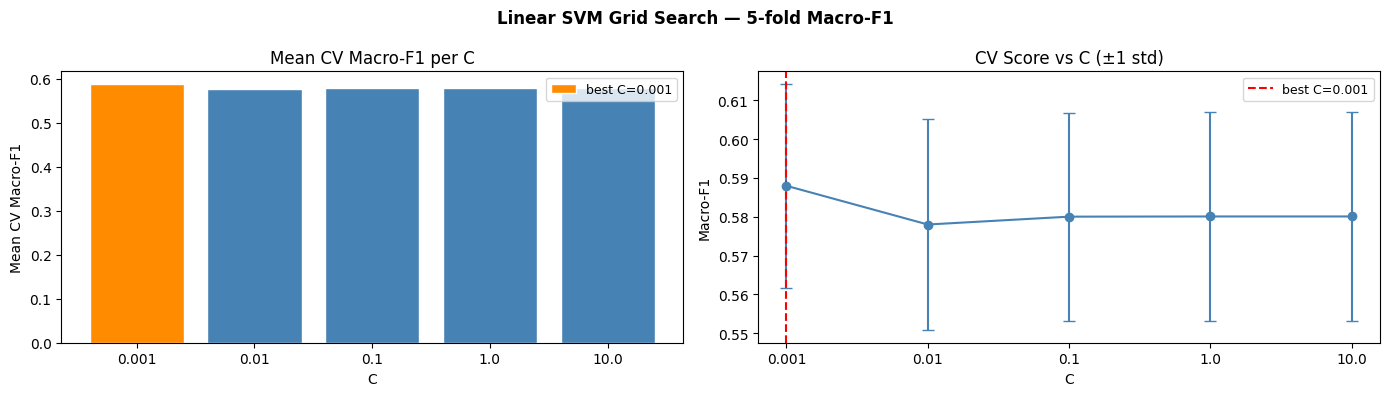

In [7]:
cv_results = pd.DataFrame(gs.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Linear SVM Grid Search — 5-fold Macro-F1',
             fontsize=12, fontweight='bold')

# Bar chart of mean CV score per C value
c_values = [str(c) for c in cv_results['param_svm__C']]
axes[0].bar(c_values, cv_results['mean_test_score'],
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('C'); axes[0].set_ylabel('Mean CV Macro-F1')
axes[0].set_title('Mean CV Macro-F1 per C')
best_idx = cv_results['mean_test_score'].idxmax()
axes[0].bar(str(best_C), cv_results.loc[best_idx, 'mean_test_score'],
            color='darkorange', edgecolor='white', label=f'best C={best_C}')
axes[0].legend(fontsize=9)

# Line plot with error bars
axes[1].errorbar(
    c_values,
    cv_results['mean_test_score'],
    yerr=cv_results['std_test_score'],
    marker='o', color='steelblue', capsize=4
)
axes[1].axvline(str(best_C), color='red', ls='--', lw=1.5,
                label=f'best C={best_C}')
axes[1].set_xlabel('C'); axes[1].set_ylabel('Macro-F1')
axes[1].set_title('CV Score vs C (±1 std)')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

## 7. Per-Class Metrics Table

In [ ]:
report = classification_report(
    y_test, y_pred, target_names=le.classes_, output_dict=True
)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(index=['accuracy'], errors='ignore')
report_df['support'] = report_df['support'].astype(int)

def highlight_metrics(col):
    per_class = list(le.classes_)
    if col.name not in {'precision', 'recall', 'f1-score'}:
        return [''] * len(col)
    vals   = col.loc[per_class]
    styles = [''] * len(col)
    styles[report_df.index.get_loc(vals.idxmax())] = 'font-weight:bold; color:#16a34a'
    styles[report_df.index.get_loc(vals.idxmin())] = 'font-weight:bold; color:#dc2626'
    return styles

report_df.style \
    .apply(highlight_metrics) \
    .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}'}) \
    .set_caption('Per-class metrics — green = best, red = worst among the 8 classes')

,precision,recall,f1-score,support
bamital,0.9976,1.0000,0.9988,417
cryptolocker,0.8048,0.9644,0.8774,7451
gameoverdga,0.4803,0.4391,0.4588,1692
goz,0.9692,0.9234,0.9457,1227
legit,0.9827,0.9926,0.9876,16000
necurs,0.1304,0.0072,0.0137,1666
newgoz,0.5276,0.5560,0.5414,1856
nivdort,0.9780,0.9994,0.9886,1691
macro avg,0.7338,0.7353,0.7265,32000
weighted avg,0.8434,0.8779,0.8560,32000


## 8. Confusion Matrix

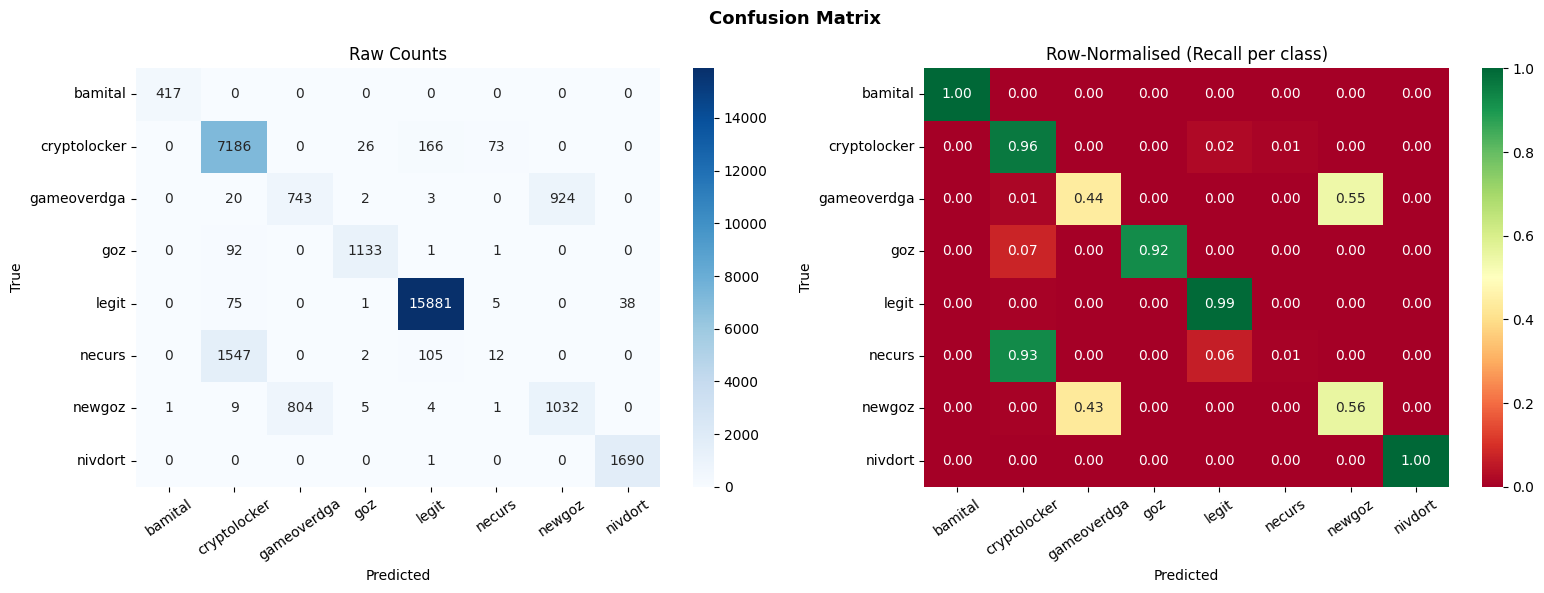

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=35)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Row-Normalised (Recall per class)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout(); plt.show()

## 9. t-SNE Embedding

PCA-50 is applied first to speed up t-SNE and reduce noise.
A balanced per-class sub-sample is used for tractability.

PCA-50 explains 7.5% of variance
Running t-SNE on 8,000 samples...
t-SNE done.


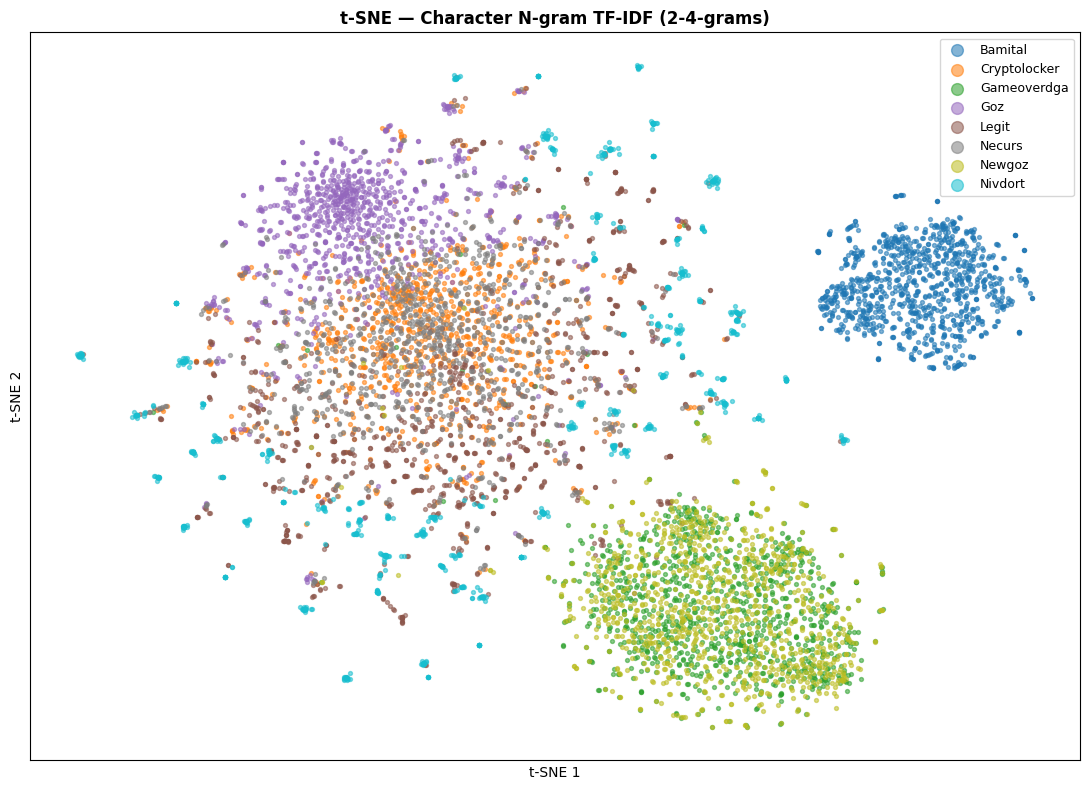

In [ ]:
EMBED_SAMPLES = 8000

idx_embed = np.concatenate([
    np.random.choice(
        np.where(y == c)[0],
        min(EMBED_SAMPLES // N_CLASSES, (y == c).sum()),
        replace=False
    ) for c in range(N_CLASSES)
])
X_embed = X_dense[idx_embed]
y_embed = y[idx_embed]

X_embed_s = StandardScaler().fit_transform(X_embed)
pca50 = PCA(n_components=50, random_state=SEED)
X_pca50 = pca50.fit_transform(X_embed_s)
print(f'PCA-50 explains {pca50.explained_variance_ratio_.sum():.1%} of variance')

print(f'Running t-SNE on {len(idx_embed):,} samples...')
X_tsne = TSNE(n_components=2, perplexity=40,
              random_state=SEED, n_jobs=-1).fit_transform(X_pca50)
print('t-SNE done.')

fig, ax = plt.subplots(figsize=(11, 8))
for c, name in enumerate(le.classes_):
    m = y_embed == c
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], c=[CLASS_COLORS[c]],
               s=8, alpha=0.55, label=name.capitalize())
ax.set_title('t-SNE — Character N-gram TF-IDF (2-4-grams)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3, fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 10. UMAP Embedding

Running UMAP on 8,000 samples...
UMAP done.


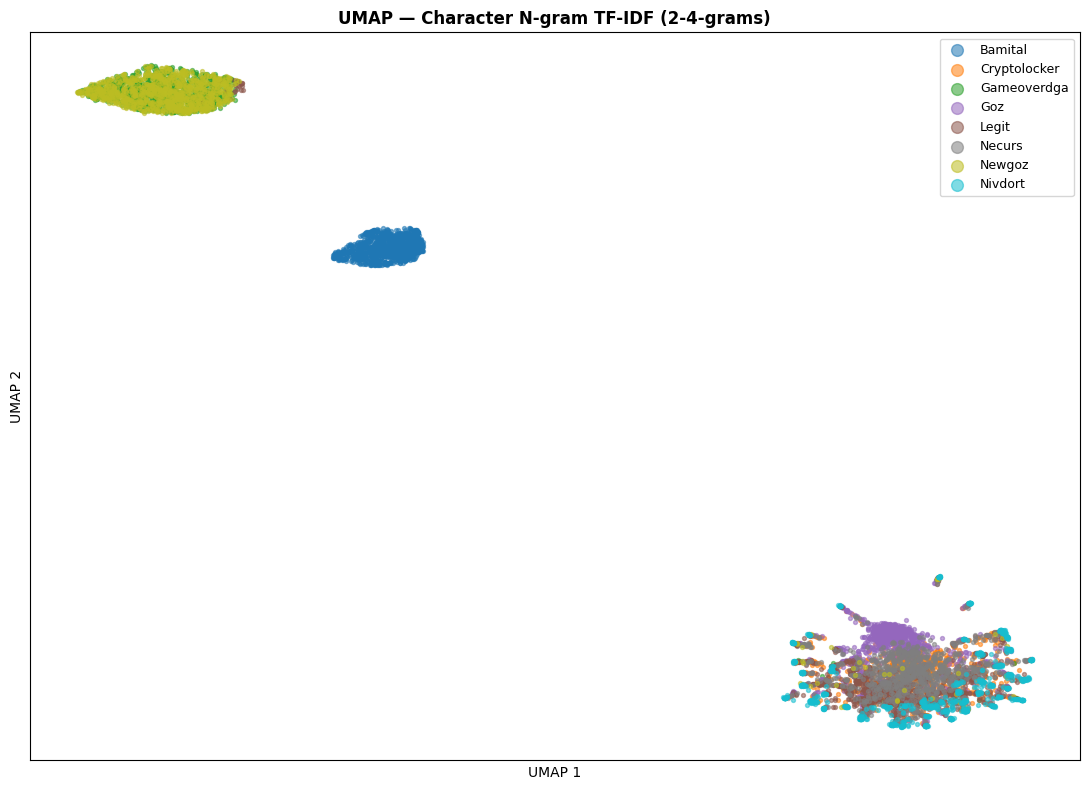

In [11]:
print(f'Running UMAP on {len(idx_embed):,} samples...')
X_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric='euclidean', random_state=SEED,
                    low_memory=False).fit_transform(X_pca50)
print('UMAP done.')

fig, ax = plt.subplots(figsize=(11, 8))
for c, name in enumerate(le.classes_):
    m = y_embed == c
    ax.scatter(X_umap[m, 0], X_umap[m, 1], c=[CLASS_COLORS[c]],
               s=8, alpha=0.55, label=name.capitalize())
ax.set_title('UMAP — Character N-gram TF-IDF (2-4-grams)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 11. t-SNE vs UMAP Side-by-Side

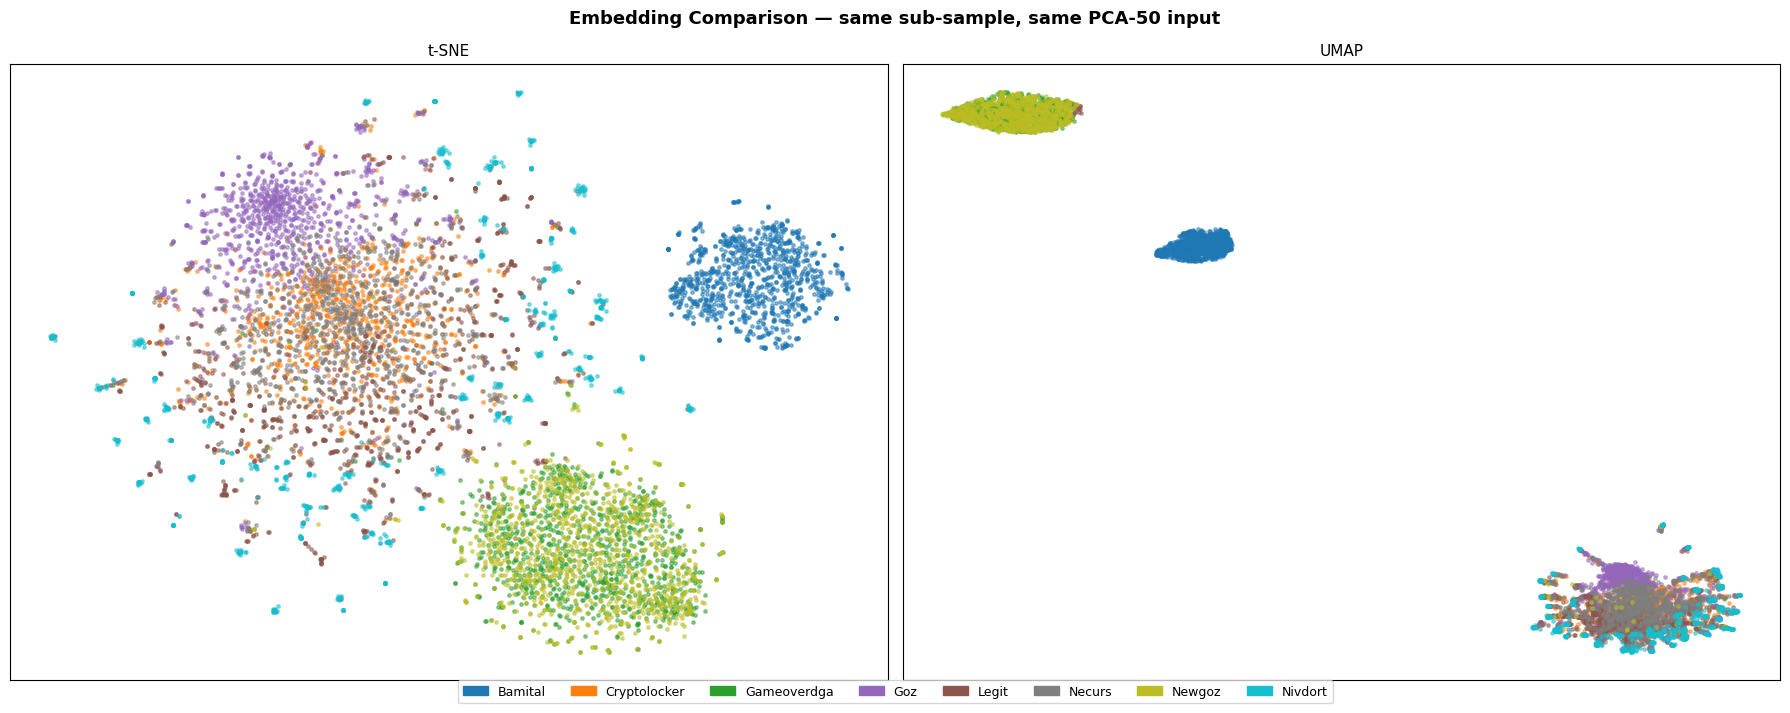

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Embedding Comparison — same sub-sample, same PCA-50 input',
             fontsize=13, fontweight='bold')

for ax, X_2d, title in zip(axes, [X_tsne, X_umap], ['t-SNE', 'UMAP']):
    for c, name in enumerate(le.classes_):
        m = y_embed == c
        ax.scatter(X_2d[m, 0], X_2d[m, 1], c=[CLASS_COLORS[c]],
                   s=6, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

handles = [mpatches.Patch(color=CLASS_COLORS[i],
           label=le.classes_[i].capitalize()) for i in range(N_CLASSES)]
fig.legend(handles=handles, loc='lower center', ncol=N_CLASSES,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.show()

## 12. Centroid Distance Matrix

Class centroids are computed in the standardised TF-IDF space.
Close centroids predict off-diagonal mass in the confusion matrix.

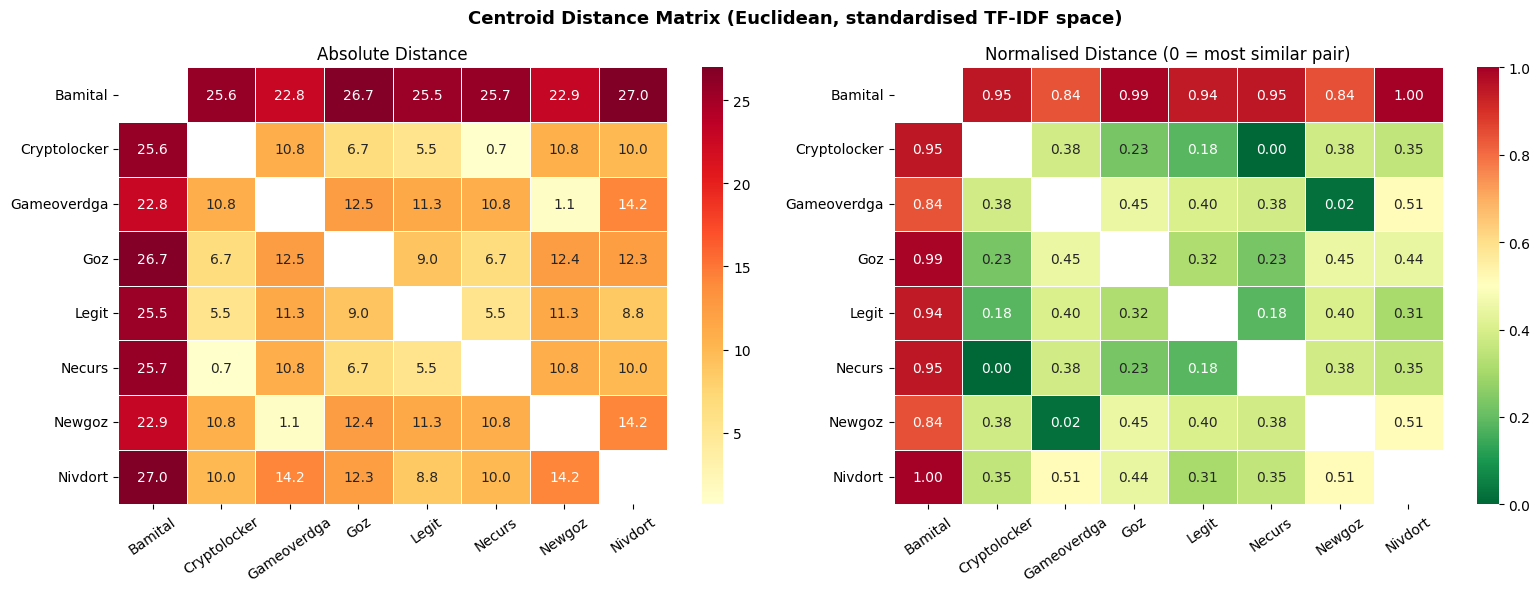

Most similar pairs:
  cryptolocker    <-> necurs           dist=0.72
  gameoverdga     <-> newgoz           dist=1.14
  cryptolocker    <-> legit            dist=5.48
Most distinct pairs:
  bamital         <-> nivdort          dist=26.96
  bamital         <-> goz              dist=26.72
  bamital         <-> necurs           dist=25.65


In [ ]:
X_dense_s = StandardScaler().fit_transform(X_dense)
centroids = np.array([X_dense_s[y == c].mean(axis=0) for c in range(N_CLASSES)])
dist_matrix = cdist(centroids, centroids, metric='euclidean')
cls_labels = [c.capitalize() for c in le.classes_]
dist_df = pd.DataFrame(dist_matrix, index=cls_labels, columns=cls_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Centroid Distance Matrix (Euclidean, standardised TF-IDF space)',
             fontsize=13, fontweight='bold')

mask_diag = np.eye(N_CLASSES, dtype=bool)
sns.heatmap(dist_df, annot=True, fmt='.1f', cmap='YlOrRd',
            mask=mask_diag, ax=axes[0], linewidths=0.5)
axes[0].set_title('Absolute Distance')
axes[0].tick_params(axis='x', rotation=35)

flat = dist_matrix[~mask_diag]
dist_norm = (dist_matrix - flat.min()) / (flat.max() - flat.min())
np.fill_diagonal(dist_norm, np.nan)
sns.heatmap(pd.DataFrame(dist_norm, index=cls_labels, columns=cls_labels),
            annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalised Distance (0 = most similar pair)')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout(); plt.show()

pairs = [(dist_matrix[i, j], le.classes_[i], le.classes_[j])
         for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)]
print('Most similar pairs:')
for d, a, b in sorted(pairs)[:3]:
    print(f'  {a:15s} <-> {b:15s}  dist={d:.2f}')
print('Most distinct pairs:')
for d, a, b in sorted(pairs, reverse=True)[:3]:
    print(f'  {a:15s} <-> {b:15s}  dist={d:.2f}')

## 13. Summary

In [ ]:
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = (y_pred == y_test).mean()
per_class_f1 = f1_score(y_test, y_pred, average=None)

easiest = le.classes_[per_class_f1.argmax()]
hardest = le.classes_[per_class_f1.argmin()]
closest = min([(dist_matrix[i,j], le.classes_[i], le.classes_[j])
               for i in range(N_CLASSES) for j in range(i+1, N_CLASSES)])

print('=' * 60)
print(' LINEAR SVM MULTI-CLASS DGA — SUMMARY')
print('=' * 60)
print(f' Kernel         : Linear  (C={best_C})')
print(f' Features       : {X_dense.shape[1]:,} TF-IDF n-grams (char_wb, 2-4)')
print(f' Test accuracy  : {accuracy:.4f}')
print(f' Macro F1       : {macro_f1:.4f}')
print(f' Micro F1       : {micro_f1:.4f}')
print(f' Weighted F1    : {weighted_f1:.4f}')
print()
print(f' Easiest class  : {easiest}  (F1={per_class_f1.max():.4f})')
print(f' Hardest class  : {hardest}  (F1={per_class_f1.min():.4f})')
print()
print(f' Closest centroid pair : {closest[1]} <-> {closest[2]}')
print(f'   dist={closest[0]:.2f} -- most likely source of confusion')
print(f' Mean latency  : {mean_latency_ms:.4f} ms/sample')
print(f' P99  latency  : {p99_latency_ms:.4f} ms/sample')
print('=' * 60)
print('\n Per-class F1:')
for cls, score in zip(le.classes_, per_class_f1):
    bar = chr(9608) * int(score * 30)
    print(f'  {cls:15s} {bar} {score:.4f}')

 LINEAR SVM MULTI-CLASS DGA — SUMMARY
 Kernel         : Linear  (C=0.001)
 Features       : 5,000 TF-IDF n-grams (char_wb, 2-4)
 Test accuracy  : 0.8779
 Macro F1       : 0.7265
 Micro F1       : 0.8779
 Weighted F1    : 0.8560

 Easiest class  : bamital  (F1=0.9988)
 Hardest class  : necurs  (F1=0.0137)

 Closest centroid pair : cryptolocker <-> necurs
   dist=0.72 -- most likely source of confusion
 Mean latency  : 0.0146 ms/sample
 P99  latency  : 0.0268 ms/sample

 Per-class F1:
  bamital         █████████████████████████████ 0.9988
  cryptolocker    ██████████████████████████ 0.8774
  gameoverdga     █████████████ 0.4588
  goz             ████████████████████████████ 0.9457
  legit           █████████████████████████████ 0.9876
  necurs           0.0137
  newgoz          ████████████████ 0.5414
  nivdort         █████████████████████████████ 0.9886


## 14. Leave-One-Family-Out (LOFO) Evaluation

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report

DGA_FAMILIES = [c for c in CLASSES if c != 'legit']
lofo_results = []

print(f'Running LOFO across {len(DGA_FAMILIES)} families...\n')

for held_out in DGA_FAMILIES:
    train_mask = dga_dataset['subclass'] != held_out
    test_mask  = dga_dataset['subclass'] == held_out

    df_train = dga_dataset[train_mask].copy()
    df_test  = dga_dataset[test_mask].copy()

    tfidf_lofo = TfidfVectorizer(
        analyzer='char_wb', ngram_range=(2, 4),
        max_features=5000, sublinear_tf=True,
    )
    X_tr_lofo = tfidf_lofo.fit_transform(df_train['domain'].tolist())
    X_te_lofo = tfidf_lofo.transform(df_test['domain'].tolist())

    le_lofo = LabelEncoder()
    y_tr_lofo = le_lofo.fit_transform(df_train['subclass'].tolist())

    pipe_lofo = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('svm', CalibratedClassifierCV(
            LinearSVC(C=best_C, class_weight='balanced',
                      max_iter=2000, random_state=SEED),
            cv=3
        ))
    ])
    pipe_lofo.fit(X_tr_lofo, y_tr_lofo)

    # Per-sample latency for this fold
    _fold_times = []
    for _start in range(0, X_te_lofo.shape[0], BATCH_SIZE_LAT):
        _batch = X_te_lofo[_start : _start + BATCH_SIZE_LAT]
        _t0 = time.perf_counter()
        pipe_lofo.predict(_batch)
        _t1 = time.perf_counter()
        _ms = (_t1 - _t0) * 1000 / _batch.shape[0]
        _fold_times.extend([_ms] * _batch.shape[0])
    _fold_arr = np.array(_fold_times)
    fold_mean_lat = round(float(_fold_arr.mean()), 4)
    fold_p99_lat  = round(float(np.percentile(_fold_arr, 99)), 4)

    y_pred_lofo = pipe_lofo.predict(X_te_lofo)
    pred_names  = le_lofo.inverse_transform(y_pred_lofo)

    detection_rate = (pred_names != 'legit').mean()

    from collections import Counter
    top_pred = Counter(pred_names).most_common(1)[0]

    lofo_results.append({
        'held_out_family' : held_out,
        'n_test' : len(df_test),
        'detection_rate' : round(detection_rate, 4),
        'top_predicted_as': top_pred[0],
        'top_pred_count' : top_pred[1],
        'top_pred_pct' : round(top_pred[1] / len(df_test), 4),
        'mean_latency_ms' : fold_mean_lat,
        'p99_latency_ms' : fold_p99_lat,
    })
    print(f'  [{held_out:15s}]  n={len(df_test):5,}  '
          f'detection={detection_rate:.2%}  '
          f'mostly_predicted_as={top_pred[0]} ({top_pred[1]/len(df_test):.1%})')

lofo_df = pd.DataFrame(lofo_results).set_index('held_out_family')
print('\nLOFO Summary Table:')
print(lofo_df.to_string())


Running LOFO across 7 families...

  [bamital        ]  n=2,086  detection=98.66%  mostly_predicted_as=newgoz (55.9%)
  [cryptolocker   ]  n=37,254  detection=92.66%  mostly_predicted_as=necurs (89.7%)
  [gameoverdga    ]  n=8,461  detection=99.99%  mostly_predicted_as=newgoz (99.5%)
  [goz            ]  n=6,136  detection=99.64%  mostly_predicted_as=cryptolocker (92.3%)
  [necurs         ]  n=8,331  detection=93.84%  mostly_predicted_as=cryptolocker (93.4%)
  [newgoz         ]  n=9,276  detection=99.92%  mostly_predicted_as=gameoverdga (99.2%)
  [nivdort        ]  n=8,456  detection=0.04%  mostly_predicted_as=legit (100.0%)

LOFO Summary Table:
                 n_test  detection_rate top_predicted_as  top_pred_count  top_pred_pct  mean_latency_ms  p99_latency_ms
held_out_family                                                                                                        
bamital            2086          0.9866           newgoz            1166        0.5590           0.0189   

### 15b. LOFO Detection Rate — Bar Chart

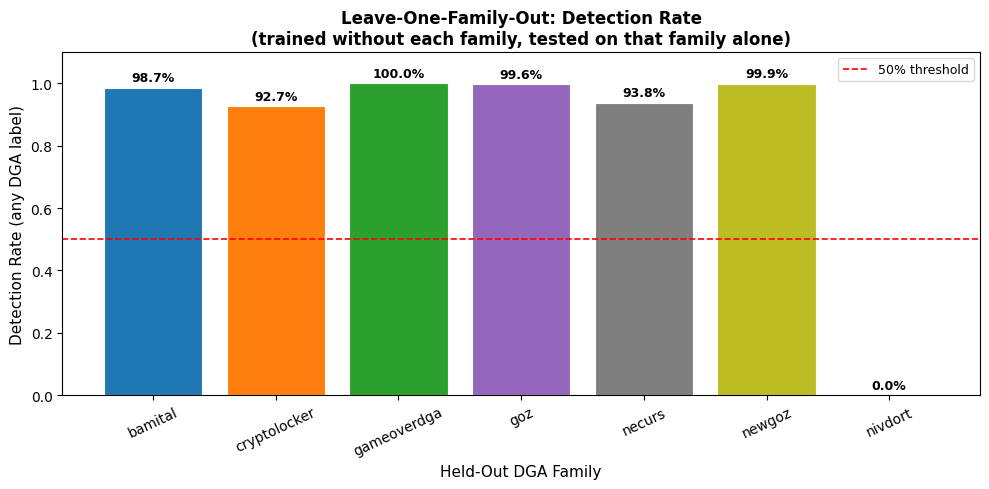


Families above 50% detection (model generalises to unseen family):
  ✓ bamital        : 98.7%
  ✓ cryptolocker   : 92.7%
  ✓ gameoverdga    : 100.0%
  ✓ goz            : 99.6%
  ✓ necurs         : 93.8%
  ✓ newgoz         : 99.9%
  ✗ nivdort        : 0.0%


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

families = lofo_df.index.tolist()
rates = lofo_df['detection_rate'].tolist()
colors = [CLASS_COLORS[CLASSES.index(f)] for f in families]

bars = ax.bar(families, rates, color=colors, edgecolor='white', linewidth=0.8)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_ylim(0, 1.1)
ax.set_xlabel('Held-Out DGA Family', fontsize=11)
ax.set_ylabel('Detection Rate (any DGA label)', fontsize=11)
ax.set_title('Leave-One-Family-Out: Detection Rate\n'
             '(trained without each family, tested on that family alone)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nFamilies above 50% detection (model generalises to unseen family):')
for f, r in zip(families, rates):
    marker = '✓' if r >= 0.5 else '✗'
    print(f'  {marker} {f:15s}: {r:.1%}')


## 16. Latency Analysis

In [ ]:
print('Main model latency (full test set)')
print(f'  Mean : {mean_latency_ms:.4f} ms/sample')
print(f'  P99  : {p99_latency_ms:.4f} ms/sample')
print()

lat_cols = ['mean_latency_ms', 'p99_latency_ms']
lat_df = lofo_df[lat_cols].copy()

mean_row = lat_df.mean(numeric_only=True).rename('MEAN')
lat_df   = pd.concat([lat_df, mean_row.to_frame().T])

lat_df.style \
    .background_gradient(cmap='YlOrRd', subset=lat_cols) \
    .format(precision=4) \
    .set_caption('Per-sample inference latency by LOFO fold (ms) — lower is better')


Main model latency (full test set)
  Mean : 0.0146 ms/sample
  P99  : 0.0268 ms/sample



,mean_latency_ms,p99_latency_ms
bamital,0.0189,0.0506
cryptolocker,0.0132,0.0256
gameoverdga,0.0179,0.0350
goz,0.0153,0.0266
necurs,0.0086,0.0150
newgoz,0.0164,0.0256
nivdort,0.0124,0.0226
MEAN,0.0147,0.0287


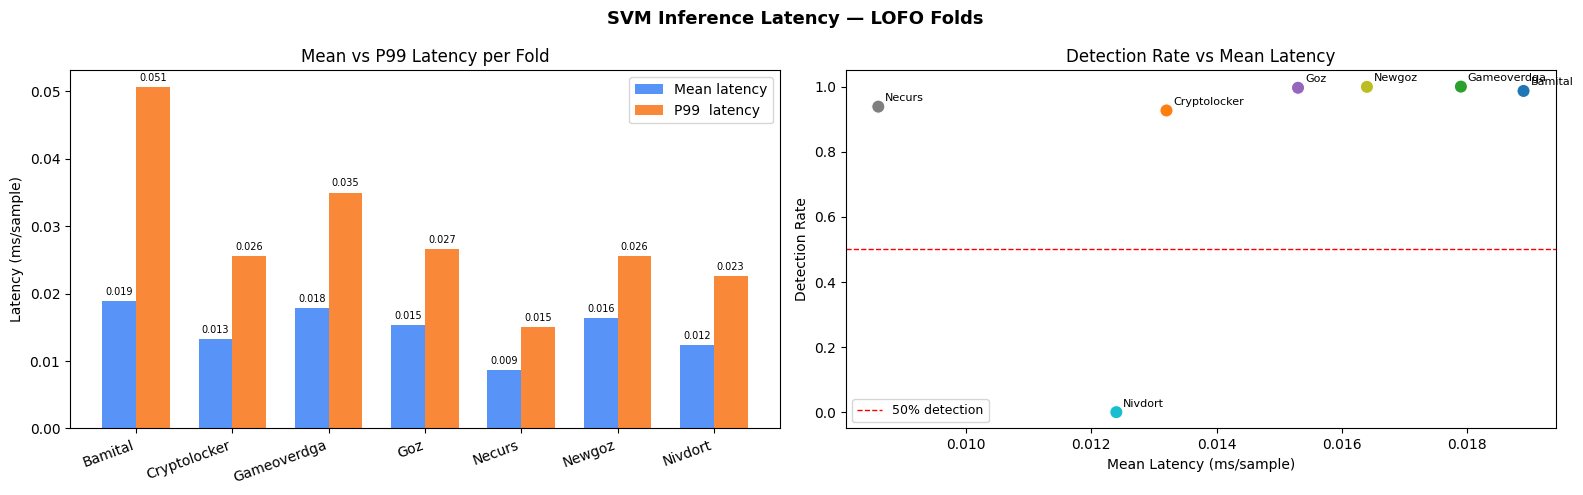

Overall mean latency (LOFO mean): 0.0147 ms/sample
Overall P99  latency (LOFO mean): 0.0287 ms/sample


In [ ]:
fam_labels = lofo_df.index.tolist()
mean_lats = lofo_df['mean_latency_ms'].tolist()
p99_lats = lofo_df['p99_latency_ms'].tolist()

x = np.arange(len(fam_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SVM Inference Latency — LOFO Folds', fontsize=13, fontweight='bold')

ax = axes[0]
b1 = ax.bar(x - width/2, mean_lats, width, label='Mean latency', color='#3b82f6', alpha=0.85)
b2 = ax.bar(x + width/2, p99_lats,  width, label='P99  latency', color='#f97316', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in fam_labels], rotation=20, ha='right')
ax.set_ylabel('Latency (ms/sample)')
ax.set_title('Mean vs P99 Latency per Fold')
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=7)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=7)
ax.legend()

ax2 = axes[1]
det_rates = lofo_df['detection_rate'].tolist()
colors_sc = [CLASS_COLORS[CLASSES.index(f)] for f in fam_labels]
ax2.scatter(mean_lats, det_rates, c=colors_sc, s=90, zorder=3, edgecolors='white', linewidths=0.8)
for fam, ml, dr in zip(fam_labels, mean_lats, det_rates):
    ax2.annotate(fam.capitalize(), (ml, dr), textcoords='offset points',
                 xytext=(5, 4), fontsize=8)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% detection')
ax2.set_xlabel('Mean Latency (ms/sample)')
ax2.set_ylabel('Detection Rate')
ax2.set_title('Detection Rate vs Mean Latency')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Overall mean latency (LOFO mean): {np.mean(mean_lats):.4f} ms/sample')
print(f'Overall P99  latency (LOFO mean): {np.mean(p99_lats):.4f} ms/sample')
